In [10]:
import pandas as pd
import os
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
from sklearn.pipeline import Pipeline
import joblib
import os

ignorewarnings = True

In [11]:
df = pd.read_excel('../data_final_pakcoy.xlsx')

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 605 entries, 0 to 604
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   plant         605 non-null    int64         
 1   day           605 non-null    int64         
 2   leaf_count    605 non-null    int64         
 3   plant_height  605 non-null    float64       
 4   leaf_length   605 non-null    float64       
 5   leaf_width    605 non-null    float64       
 6   date          605 non-null    datetime64[ns]
 7   ph            605 non-null    float64       
 8   ppm           605 non-null    float64       
 9   water_temp    605 non-null    float64       
 10  air_temp      605 non-null    float64       
 11  humidity      605 non-null    float64       
dtypes: datetime64[ns](1), float64(8), int64(3)
memory usage: 56.8 KB


In [13]:
df['leaf_width'].fillna(df['leaf_width'].mean(), inplace=True)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 605 entries, 0 to 604
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   plant         605 non-null    int64         
 1   day           605 non-null    int64         
 2   leaf_count    605 non-null    int64         
 3   plant_height  605 non-null    float64       
 4   leaf_length   605 non-null    float64       
 5   leaf_width    605 non-null    float64       
 6   date          605 non-null    datetime64[ns]
 7   ph            605 non-null    float64       
 8   ppm           605 non-null    float64       
 9   water_temp    605 non-null    float64       
 10  air_temp      605 non-null    float64       
 11  humidity      605 non-null    float64       
dtypes: datetime64[ns](1), float64(8), int64(3)
memory usage: 56.8 KB


In [15]:
def categorize_ppm(value):
    if value < 950:
        return "Very Low"
    elif value < 1050:
        return "Low"
    elif value < 1150:
        return "Medium"
    else:
        return "High"

df['ppm_category'] = df['ppm'].apply(categorize_ppm)

In [16]:
print(df[['ppm', 'ppm_category']].head(10))

          ppm ppm_category
0  888.677043     Very Low
1  888.677043     Very Low
2  888.677043     Very Low
3  888.677043     Very Low
4  888.677043     Very Low
5  888.677043     Very Low
6  888.677043     Very Low
7  888.677043     Very Low
8  888.677043     Very Low
9  888.677043     Very Low


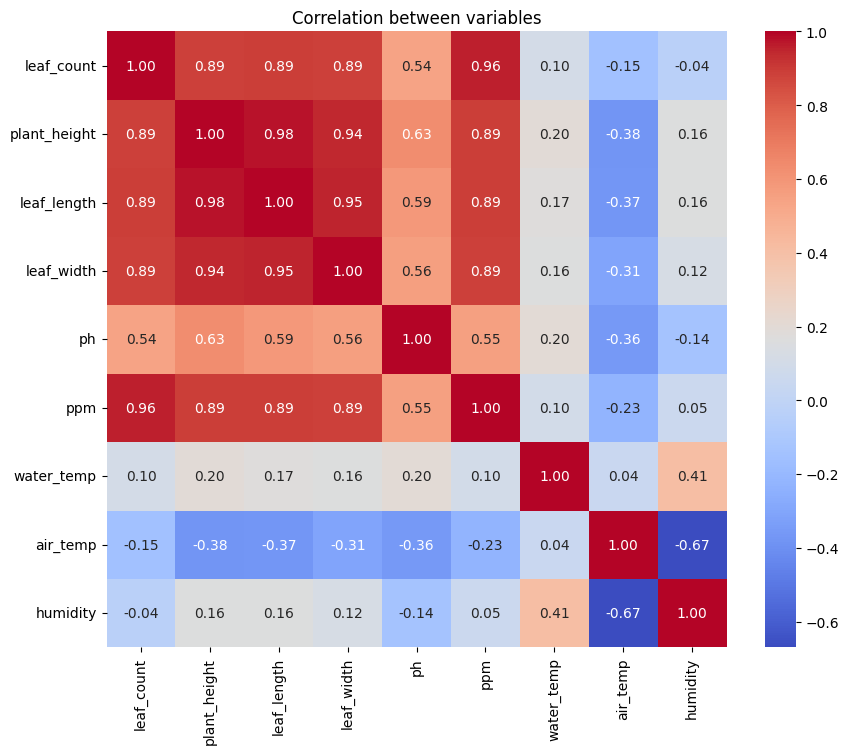

In [17]:
corr = df[['leaf_count','plant_height','leaf_length','leaf_width','ph','ppm','water_temp','air_temp','humidity']].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation between variables')
plt.show()

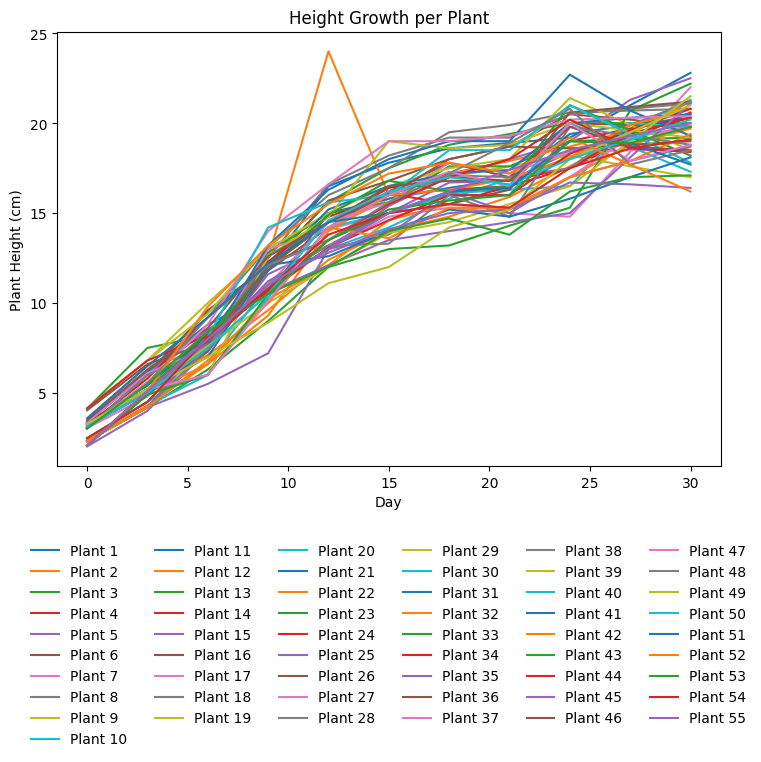

In [18]:
plt.figure(figsize=(8, 8))

for plant in df['plant'].dropna().unique():
    subset = df[df['plant'] == plant]
    plt.plot(subset['day'], subset['plant_height'], label=f'Plant {plant}')
    
plt.xlabel('Day')
plt.ylabel('Plant Height (cm)')
plt.title('Height Growth per Plant')
plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=6,
    frameon=False
)
plt.tight_layout()
plt.show()

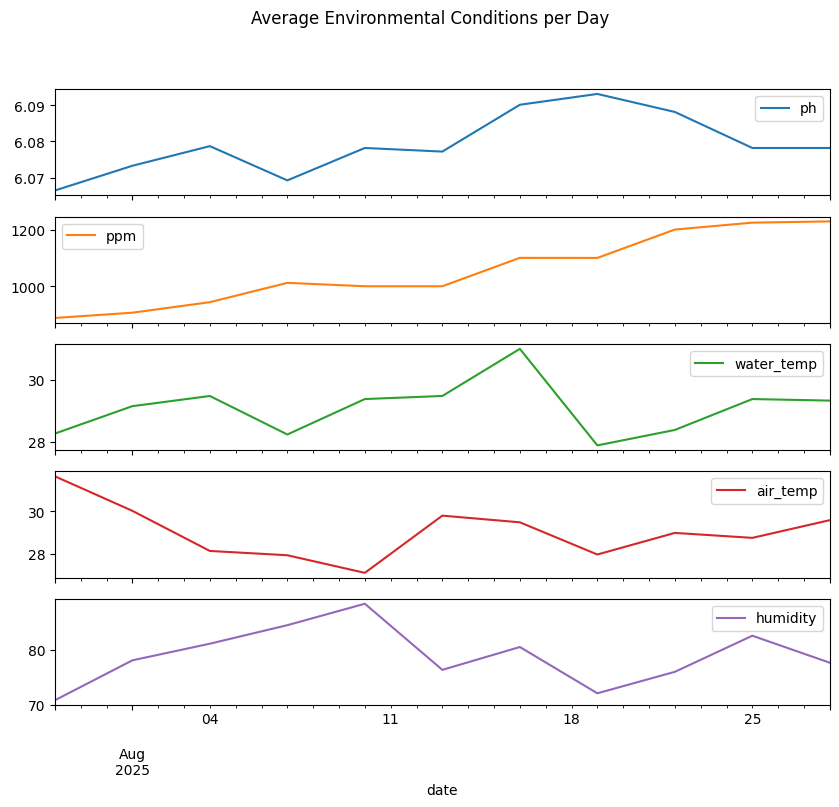

In [19]:
df.groupby('date')[['ph','ppm','water_temp','air_temp','humidity']].mean().plot(subplots=True, figsize=(10,8))
plt.suptitle('Average Environmental Conditions per Day')
plt.show()

In [20]:
numeric_cols = ['ph','ppm','water_temp','air_temp','humidity',
                'leaf_count','plant_height','leaf_length','leaf_width']
numeric_cols = [c for c in numeric_cols if c in df.columns]

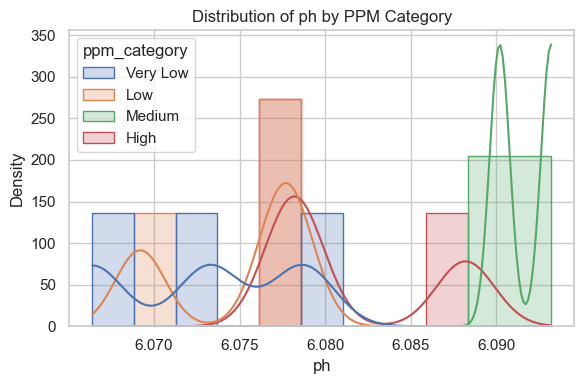

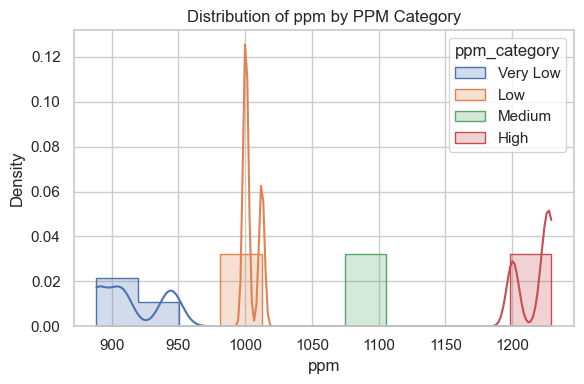

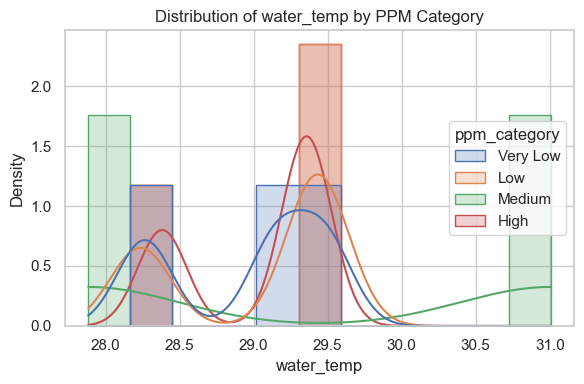

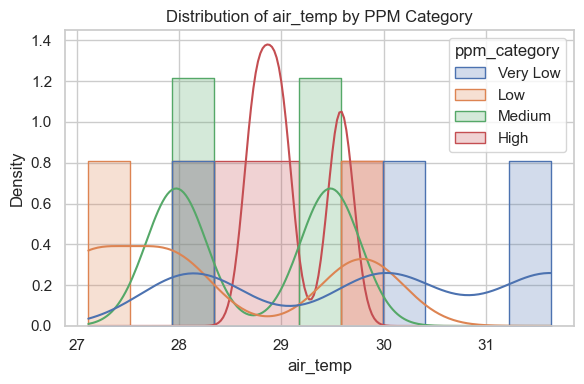

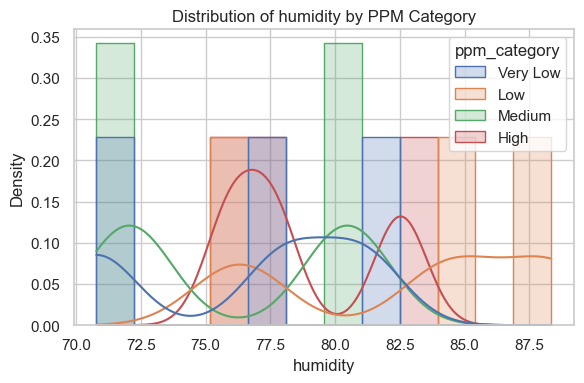

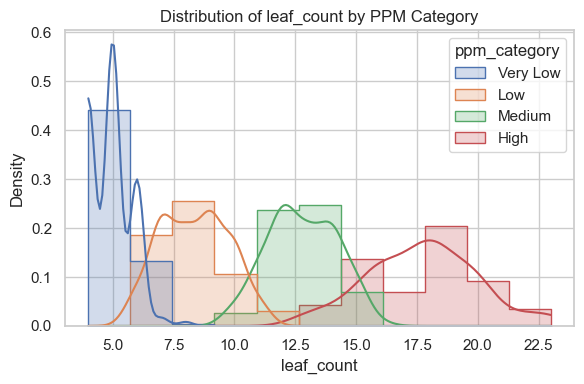

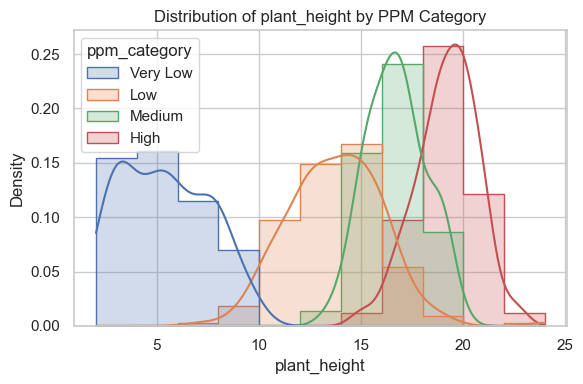

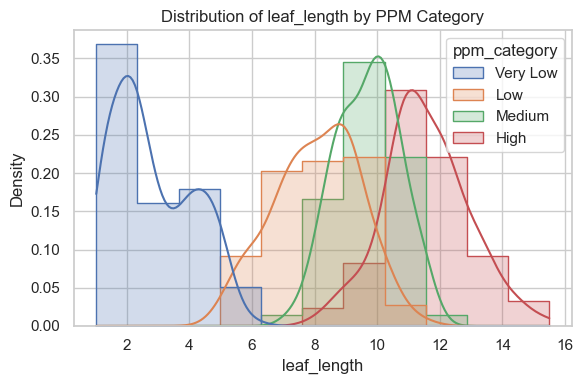

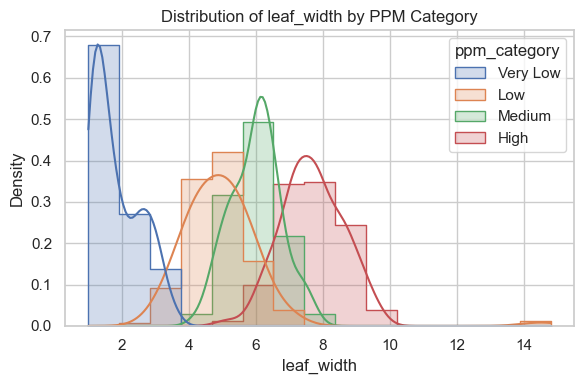

In [21]:
sns.set(style="whitegrid", context="notebook")

cat_order = [c for c in ["Very Low","Low","Medium","High"] if c in df['ppm_category'].unique()]

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(data=df, x=col, hue='ppm_category', element='step',
                 stat='density', common_norm=False, kde=True, hue_order=cat_order)
    plt.title(f'Distribution of {col} by PPM Category')
    plt.tight_layout()
    plt.show()

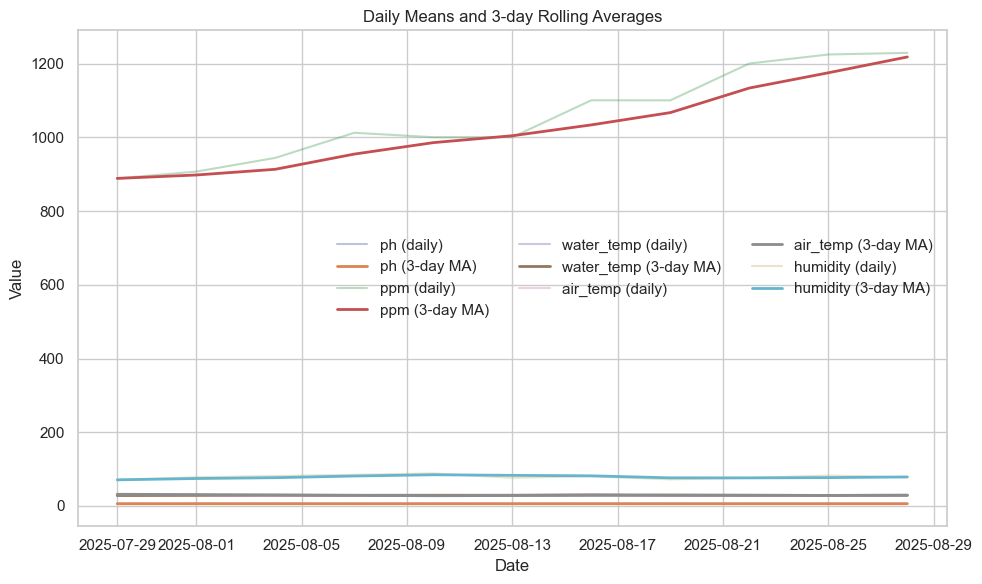

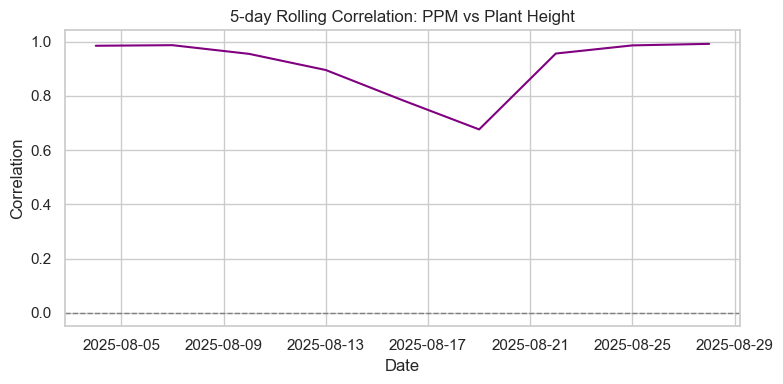

In [22]:
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    daily = df.groupby('date')[['ph','ppm','water_temp','air_temp','humidity',
                                'plant_height']].mean().sort_index()
    roll = daily.rolling(window=3, min_periods=1).mean()

    plt.figure(figsize=(10,6))
    for col in ['ph','ppm','water_temp','air_temp','humidity']:
        if col in daily.columns:
            plt.plot(daily.index, daily[col], alpha=0.4, label=f'{col} (daily)')
            plt.plot(roll.index, roll[col], linewidth=2, label=f'{col} (3-day MA)')
    plt.title('Daily Means and 3-day Rolling Averages')
    plt.xlabel('Date'); plt.ylabel('Value')
    plt.legend(ncol=3, frameon=False)
    plt.tight_layout()
    plt.show()

    # Rolling correlation between PPM and Plant Height (daily means)
    if {'ppm','plant_height'}.issubset(daily.columns):
        rolling_corr = daily['ppm'].rolling(5, min_periods=3).corr(daily['plant_height'])
        plt.figure(figsize=(8,4))
        plt.plot(rolling_corr.index, rolling_corr, color='purple')
        plt.axhline(0, color='gray', linestyle='--', linewidth=1)
        plt.title('5-day Rolling Correlation: PPM vs Plant Height')
        plt.xlabel('Date'); plt.ylabel('Correlation')
        plt.tight_layout()
        plt.show()

### Semua sensor + tanaman

In [23]:
X = df[['ph', 'water_temp', 'air_temp', 'humidity',
        'leaf_count', 'plant_height', 'leaf_length', 'leaf_width']]

y = df['ppm_category']

In [24]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [25]:
label_map = dict(zip(le.classes_, le.transform(le.classes_)))
print("Mapping label:", label_map)

Mapping label: {'High': 0, 'Low': 1, 'Medium': 2, 'Very Low': 3}


In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [27]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [28]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

In [29]:
y_pred = model.predict(X_test_scaled)
print(classification_report(y_test, y_pred, target_names=le.classes_))

              precision    recall  f1-score   support

        High       1.00      1.00      1.00        46
         Low       1.00      1.00      1.00        51
      Medium       1.00      1.00      1.00        27
    Very Low       1.00      1.00      1.00        58

    accuracy                           1.00       182
   macro avg       1.00      1.00      1.00       182
weighted avg       1.00      1.00      1.00       182



        Feature  Importance
0            ph    0.224017
4    leaf_count    0.175600
5  plant_height    0.172879
7    leaf_width    0.128868
2      air_temp    0.102657
6   leaf_length    0.084497
3      humidity    0.064890
1    water_temp    0.046591


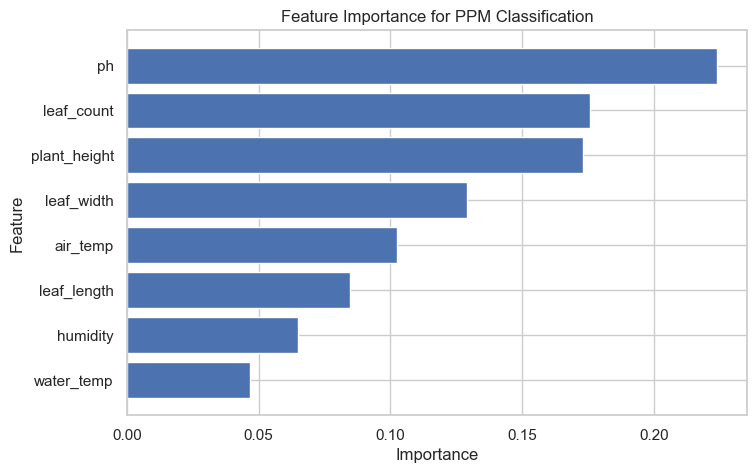

In [30]:
importance = model.feature_importances_
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

# Tampilkan 10 fitur paling penting
print(feature_importance)

# Visualisasi
plt.figure(figsize=(8,5))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance for PPM Classification')
plt.gca().invert_yaxis()
plt.show()

In [31]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(n_estimators=100, random_state=42))
])

In [32]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='f1_macro', n_jobs=-1)
print(f"CV f1_macro: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

CV f1_macro: 0.9985 ± 0.0030


In [33]:
pipeline.fit(X_train, y_train)
y_pred_pipe = pipeline.predict(X_test)
print(classification_report(y_test, y_pred_pipe, target_names=le.classes_))

              precision    recall  f1-score   support

        High       1.00      1.00      1.00        46
         Low       1.00      1.00      1.00        51
      Medium       1.00      1.00      1.00        27
    Very Low       1.00      1.00      1.00        58

    accuracy                           1.00       182
   macro avg       1.00      1.00      1.00       182
weighted avg       1.00      1.00      1.00       182



In [34]:
out_dir = 'model_pakcoy_all_data'
os.makedirs(out_dir, exist_ok=True)

In [36]:
joblib.dump(pipeline, os.path.join(out_dir, 'pakcoy_rf_pipeline.joblib'))
joblib.dump(pipeline.named_steps['scaler'], os.path.join(out_dir, 'pakcoy_scaler.joblib'))
joblib.dump(le, os.path.join(out_dir, 'pakcoy_label_encoder.joblib'))
joblib.dump(list(X.columns), os.path.join(out_dir, 'pakcoy_feature_names.joblib'))
metadata = {'cv_scores': cv_scores.tolist(), 'random_state': 42}
joblib.dump(metadata, os.path.join(out_dir, 'pakcoy_metadata.joblib'))

['model_pakcoy_all_data\\pakcoy_metadata.joblib']

### Hanya Sensor

In [37]:
X2 = df[['ph', 'water_temp', 'air_temp', 'humidity']]

y2 = df['ppm_category']

In [38]:
le2 = LabelEncoder()
y2_encoded = le2.fit_transform(y2)

In [39]:
label_map2 = dict(zip(le2.classes_, le2.transform(le2.classes_)))
print("Mapping label:", label_map2)

Mapping label: {'High': 0, 'Low': 1, 'Medium': 2, 'Very Low': 3}


In [40]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y2_encoded, test_size=0.3, random_state=42
)

In [41]:
scaler2 = StandardScaler()
X_train2_scaled = scaler2.fit_transform(X_train2)
X_test2_scaled = scaler2.transform(X_test2)

In [42]:
model2 = RandomForestClassifier(n_estimators=100, random_state=42)
model2.fit(X_train2_scaled, y_train2)

RandomForestClassifier(random_state=42)

In [43]:
y_pred2 = model2.predict(X_test2_scaled)
print(classification_report(y_test2, y_pred2, target_names=le2.classes_))

              precision    recall  f1-score   support

        High       1.00      1.00      1.00        46
         Low       1.00      1.00      1.00        51
      Medium       1.00      1.00      1.00        27
    Very Low       1.00      1.00      1.00        58

    accuracy                           1.00       182
   macro avg       1.00      1.00      1.00       182
weighted avg       1.00      1.00      1.00       182



      Feature  Importance
0          ph    0.368057
2    air_temp    0.331175
1  water_temp    0.176786
3    humidity    0.123981


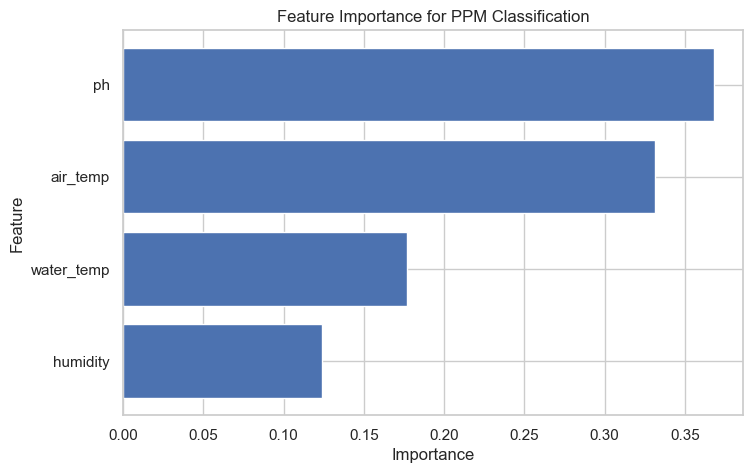

In [44]:
importance2 = model2.feature_importances_
feature_importance2 = pd.DataFrame({
    'Feature': X2.columns,
    'Importance': importance2
}).sort_values(by='Importance', ascending=False)

# Tampilkan 10 fitur paling penting
print(feature_importance2)

# Visualisasi
plt.figure(figsize=(8,5))
plt.barh(feature_importance2['Feature'], feature_importance2['Importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance for PPM Classification')
plt.gca().invert_yaxis()
plt.show()

In [45]:
pipeline2 = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(n_estimators=100, random_state=42))
])

In [46]:
cv2 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores2 = cross_val_score(pipeline2, X2, y2, cv=cv2, scoring='f1_macro', n_jobs=-1)
print(f"CV f1_macro: {cv_scores2.mean():.4f} ± {cv_scores2.std():.4f}")

CV f1_macro: 1.0000 ± 0.0000


In [47]:
pipeline2.fit(X_train2, y_train2)
y_pred_pipe2 = pipeline2.predict(X_test2)
print(classification_report(y_test2, y_pred_pipe2, target_names=le2.classes_))

              precision    recall  f1-score   support

        High       1.00      1.00      1.00        46
         Low       1.00      1.00      1.00        51
      Medium       1.00      1.00      1.00        27
    Very Low       1.00      1.00      1.00        58

    accuracy                           1.00       182
   macro avg       1.00      1.00      1.00       182
weighted avg       1.00      1.00      1.00       182



In [48]:
out_dir2 = 'model_pakcoy_sensor_data'
os.makedirs(out_dir2, exist_ok=True)

In [49]:
joblib.dump(pipeline2, os.path.join(out_dir2, 'pakcoy_rf_pipeline.joblib'))
joblib.dump(pipeline2.named_steps['scaler'], os.path.join(out_dir2, 'pakcoy_scaler.joblib'))
joblib.dump(le2, os.path.join(out_dir2, 'pakcoy_label_encoder.joblib'))
joblib.dump(list(X2.columns), os.path.join(out_dir2, 'pakcoy_feature_names.joblib'))
metadata = {'cv_scores': cv_scores2.tolist(), 'random_state': 42}
joblib.dump(metadata, os.path.join(out_dir2, 'pakcoy_metadata.joblib'))

['model_pakcoy_sensor_data\\pakcoy_metadata.joblib']